# Вычисление модифицированного гамильтониана в Sage
М.А. Коняева, М.Д. Малых, 2025

ПО для одноименной статьи в DCM. 

## Введение

In [2]:
load('fdm.sage')

In [3]:
a=0.166
T=100
N=200
var('p,q,t')
H = p^2 / 2 + q^2 / 2 + a * q^3
B=symplectic_tableau(1)[0]
pr1=Initial_problem([p,q],[diff(H,q),-diff(H,p)],[0,1],T)

In [4]:
sol2=irk(pr1, N=N, eps=10^-10, M=10^2, tableau=B)

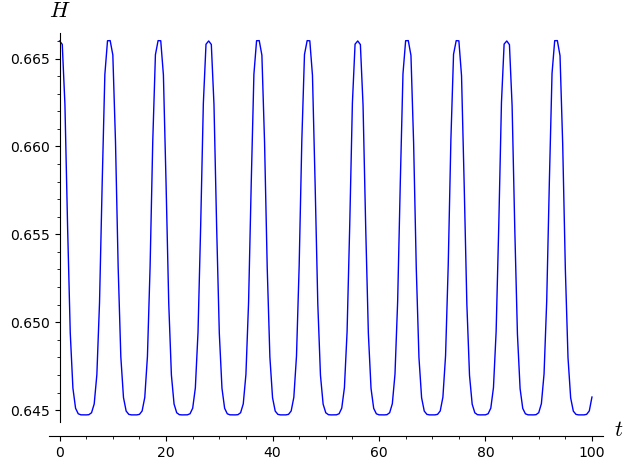

In [5]:
sol2.plot(t,H, axes_labels=['$t$','$H$'])

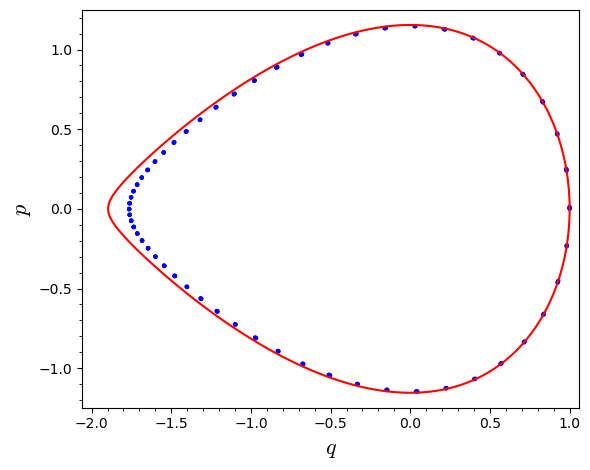

In [6]:
sol2.plot(q,p, points=True)+\
implicit_plot(H==H.subs([p==0,q==1]), (q,-2,1), (p,-1.2,1.2), color='red')

Ричардсон

In [7]:
k=8
@parallel
def foo(n):
    return irk(pr1, N=N*2^n, eps=10^-10, M=10^2, tableau=B)
L=foo([n for n in range(k)])
L1=list(L)

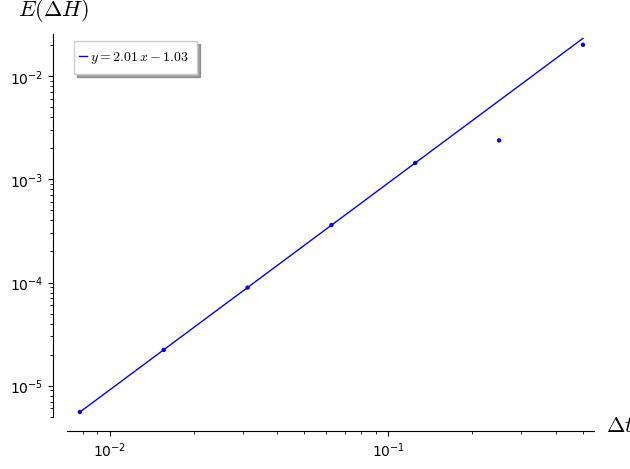

In [8]:
richardson_plot([L1[n][1] for n in range(k)],H,100, nmin=2, axes_labels=['$\\Delta t$', '$E(\\Delta H)$'])

## Программа для вычисления модифицированного гамильтониана

In [384]:
# Konyaeva, ver. 0.1
def mod_ham(H,scheme,r):
    r=r-1
    F=function('F')(p,q)
    H=H+F*dt^r
    P=-diff(H,q)
    Q=diff(H,p)
    D=lambda u: diff(u,p)*P+diff(u,q)*Q
    PP=p+dt*P
    R=P
    for i in range(r):
        R=D(R)
        PP=PP+R*dt^(i+2)/factorial(i+2)
    QQ=q+dt*Q
    R=Q
    for i in range(r):
        R=D(R)
        QQ=QQ+R*dt^(i+2)/factorial(i+2)
    S=[pp==(PP).series(dt,r+2).truncate(), qq==(QQ).series(dt,r+2).truncate()]
    eqs=[eq.subs(S).series(dt,r+2).coefficient(dt^(r+1)) for eq in scheme]
    Fq=F.diff(q).subs(solve(eqs[0], F.diff(q)))
    Fp=F.diff(p).subs(solve(eqs[1], F.diff(p)))
    if Fq.diff(p)==Fp.diff(q):
        F1=Fq.integral(q)
        F2=F1+(Fp-F1.diff(p)).integral(p)
        return H.subs(F==F2)
    else:
        return [Fp,Fq]


## Раздельная схема

In [385]:
var('p,q,dt,pp,qq')
T=function('T')(p)
U=function('U')(q)
H=T+U
scheme=[pp-p + diff(H,q).subs(q=qq)*dt, qq-q-diff(H,p)*dt]
H2=mod_ham(H,scheme,2)
H2

1/2*dt*diff(T(p), p)*diff(U(q), q) + T(p) + U(q)

In [386]:
H3=mod_ham(H2,scheme,3)
H3

1/12*(diff(T(p), p, p)*diff(U(q), q)^2 + diff(T(p), p)^2*diff(U(q), q, q))*dt^2 + 1/2*dt*diff(T(p), p)*diff(U(q), q) + T(p) + U(q)

## Схема средней точки

In [387]:
var('p,q,dt,pp,qq')
T=function('T')(p)
U=function('U')(q)
H=T+U
scheme=[pp-p + diff(H,q).subs(q=(q+qq)/2)*dt, qq-q-diff(H,p).subs(p=(p+pp)/2)*dt]
scheme

[dt*D[0](U)(1/2*q + 1/2*qq) - p + pp, -dt*D[0](T)(1/2*p + 1/2*pp) - q + qq]

In [388]:
H3=mod_ham(H,scheme,3)
H3

-1/24*(diff(T(p), p, p)*diff(U(q), q)^2 + diff(T(p), p)^2*diff(U(q), q, q))*dt^2 + T(p) + U(q)

In [389]:
mod_ham(H3,scheme,4)

-1/24*(diff(T(p), p, p)*diff(U(q), q)^2 + diff(T(p), p)^2*diff(U(q), q, q))*dt^2 + T(p) + U(q)

Не может проинтегрировать:

In [368]:
mod_ham(H3,scheme,5)

1/5760*dt^4*(6*integrate(10*diff(T(p), p, p)*diff(T(p), p, p, p)*diff(U(q), q)^2*diff(U(q), q, q), p) + 6*integrate(-2*diff(T(p), p)*diff(T(p), p, p, p, p)*diff(U(q), q)^2*diff(U(q), q, q), p) + integrate(28*diff(T(p), p, p, p, p)*diff(U(q), q)^3*diff(U(q), q, q), q) + 6*integrate(2*diff(T(p), p)*diff(T(p), p, p)^2*diff(U(q), q, q)^2, p) + 6*integrate(diff(T(p), p)^2*diff(T(p), p, p, p)*diff(U(q), q, q)^2, p) + integrate(72*diff(T(p), p, p)^2*diff(U(q), q)*diff(U(q), q, q)^2, q) + integrate(-24*diff(T(p), p)*diff(T(p), p, p, p)*diff(U(q), q)*diff(U(q), q, q)^2, q) + 6*integrate(-4*diff(T(p), p)*diff(T(p), p, p)^2*diff(U(q), q)*diff(U(q), q, q, q), p) + 6*integrate(-2*diff(T(p), p)^2*diff(T(p), p, p, p)*diff(U(q), q)*diff(U(q), q, q, q), p) + integrate(36*diff(T(p), p, p)^2*diff(U(q), q)^2*diff(U(q), q, q, q), q) + integrate(-12*diff(T(p), p)*diff(T(p), p, p, p)*diff(U(q), q)^2*diff(U(q), q, q, q), q) + integrate(60*diff(T(p), p)^2*diff(T(p), p, p)*diff(U(q), q, q)*diff(U(q), q, q, q), 

### Линейный осциллятор

In [399]:
H = p^2  + q^2 / 2
scheme=[pp-p + diff(H,q).subs(q=(q+qq)/2)*dt, qq-q-diff(H,p).subs(p=(p+pp)/2)*dt]

In [400]:
mod_ham(H,scheme,3)

-1/12*(2*p^2 + q^2)*dt^2 + p^2 + 1/2*q^2

Теорема Купера работает!

### Нелинейный осиллятор

In [422]:
var('p,q,dt,pp,qq,a')
H=p^2 / 2 + q^2 / 2 + a * q^3
scheme=[pp-p + diff(H,q).subs(q=(q+qq)/2)*dt, qq-q-diff(H,p).subs(p=(p+pp)/2)*dt]

In [423]:
H3=mod_ham(H,scheme,3)
H3

a*q^3 - 1/24*(9*a^2*q^4 + 6*a*p^2*q + 6*a*q^3 + p^2 + q^2)*dt^2 + 1/2*p^2 + 1/2*q^2

In [425]:
H4=mod_ham(H3,scheme,4)
H4

a*q^3 - 1/24*(9*a^2*q^4 + 6*a*p^2*q + 6*a*q^3 + p^2 + q^2)*dt^2 + 1/2*p^2 + 1/2*q^2

In [428]:
H5=mod_ham(H3,scheme,5)
H5

1/160*(54*a^3*q^5 + 45*a^2*q^4 + 10*a*p^2*q + 12*a*q^3 + (30*a^2*p^2 + 1)*q^2 + p^2)*dt^4 + a*q^3 - 1/24*(9*a^2*q^4 + 6*a*p^2*q + 6*a*q^3 + p^2 + q^2)*dt^2 + 1/2*p^2 + 1/2*q^2

## Численный пример

In [412]:
a=166/1000
T=100
N=200
H = p^2 / 2 + q^2 / 2 + a * q^3
load('fdm.sage')
pr1=Initial_problem([p,q],[diff(H,q),-diff(H,p)],[0,1],T)

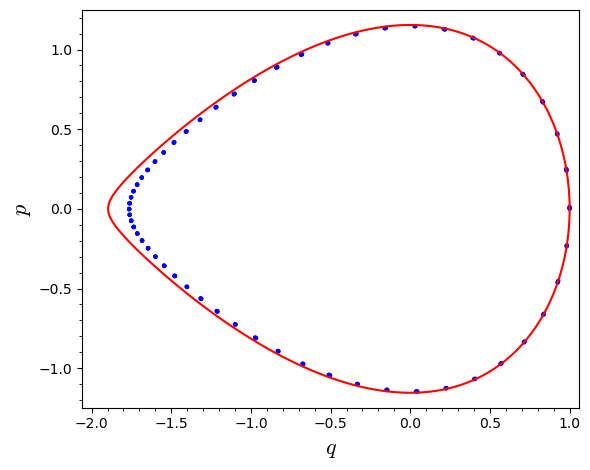

In [413]:
var('t')
B=symplectic_tableau(1)[0]
sol2=irk(pr1, N=N, eps=10^-10, M=10^2, tableau=B)
sol2.plot(q,p, points=True)+\
implicit_plot(H==H.subs([p==0,q==1]), (q,-2,1), (p,-1.2,1.2), color='red')

In [414]:
var('p,q,dt,pp,qq')
scheme=[pp-p + diff(H,q).subs(q=(q+qq)/2)*dt, qq-q-diff(H,p).subs(p=(p+pp)/2)*dt]
H3=mod_ham(H,scheme,3)
H3

-1/6000000*(62001*q^4 + 249000*p^2*q + 249000*q^3 + 250000*p^2 + 250000*q^2)*dt^2 + 83/500*q^3 + 1/2*p^2 + 1/2*q^2

In [415]:
H4=mod_ham(H3,scheme,4)
H4

-1/6000000*(62001*q^4 + 249000*p^2*q + 249000*q^3 + 250000*p^2 + 250000*q^2)*dt^2 + 83/500*q^3 + 1/2*p^2 + 1/2*q^2

In [416]:
H5=mod_ham(H4,scheme,5)
H5

1/10000000000*(15438249*q^5 + 77501250*q^4 + 103750000*p^2*q + 2500*(20667*p^2 + 25000)*q^2 + 124500000*q^3 + 62500000*p^2)*dt^4 - 1/6000000*(62001*q^4 + 249000*p^2*q + 249000*q^3 + 250000*p^2 + 250000*q^2)*dt^2 + 83/500*q^3 + 1/2*p^2 + 1/2*q^2

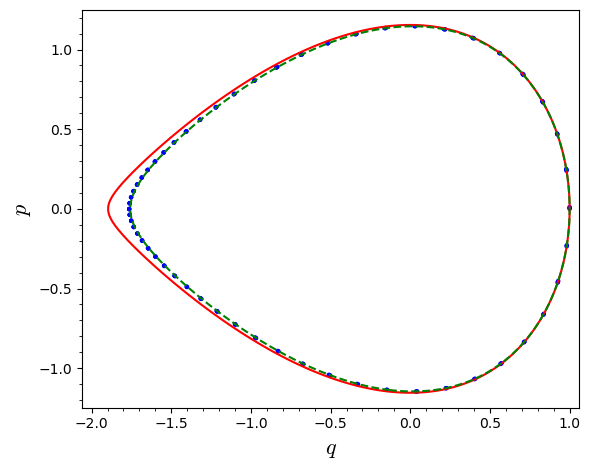

In [417]:
gr=sol2.plot(q,p, points=True)+\
implicit_plot(H==H.subs([p==0,q==1]), (q,-2,1), (p,-1.2,1.2), color='red')+\
implicit_plot(H3.subs([dt==T/N])==H3.subs([p==0,q==1,dt==T/N]), (q,-2,1), (p,-1.2,1.2), color='green', linestyle='--')
gr

In [418]:
gr.save('pq.pdf')

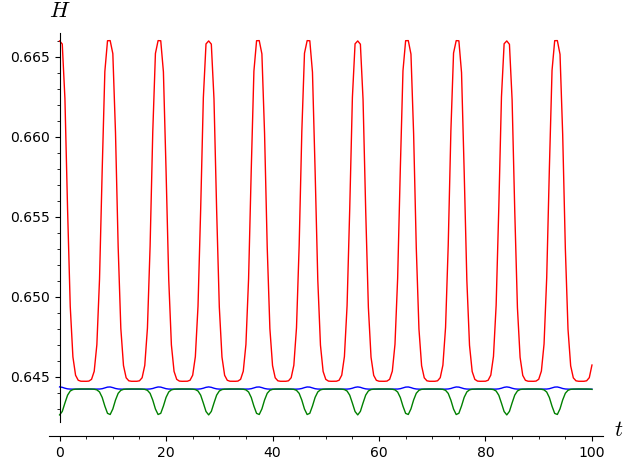

In [419]:
gr=sol2.plot(t,H5.subs(dt==T/N), color='blue')+sol2.plot(t,H, color='red')+sol2.plot(t,H3.subs(dt==T/N), color='green', axes_labels=['$t$','$H$'])
gr

In [420]:
gr.save('tH.pdf')